# 03 — Create charactor good bad profiles

## What this notebook does

This notebook creates character-level magical profiles based on the spells used by each character. It uses the output from the previous dialogue-matching notebook, `character_spell_df.csv`, where spell incantations have already been matched to characters in the movie dialogue and linked to the spell-topic probabilities from the LDA model.

The main idea is to move from **spell-level topic distributions** to **character-level topic profiles**. Each spell has probabilities for the learned topics, and each character may use some spells more than once. Therefore, the notebook weights each spell's topic probabilities by how often the character uses that spell. This means that spells used many times have a larger influence on the character's final magical profile than spells used only once.

For each character, the notebook calculates an average topic distribution across all spells they use. This produces a probabilistic profile showing whether the character is more associated with, for example, control/utility magic, defensive/healing magic, or revealing/other magic. The notebook also identifies each character's dominant topic and calculates a topic concentration score, which indicates whether a character has a strong dominant profile or a more mixed magical profile.

## What this notebook produces

The main output of this notebook is a character-level topic profile table. For each character, the table includes:

- the character name
- the weighted probability for each spell topic
- the dominant topic
- a human-readable character profile label
- a topic concentration score showing how mixed or concentrated the character's profile is

The notebook also produces several visualizations to explore the character profiles, including stacked bar charts, heatmaps, PCA plots, radar charts, ternary plots, clustering diagrams, and other exploratory plots. These visualizations help compare characters based on the types of spells they use and show how characters are positioned in the learned magical topic space.

Overall, this notebook is the final aggregation step in the project. The first notebook learns topics from spells, the second notebook connects spells to characters through dialogue, and this notebook uses those connections to create character-level magical profiles.

### Pakages

In [47]:
import pandas as pd
import plotly.express as px

### Loading data

In [48]:
# Load already-integrated Person 2 output
character_spells = pd.read_csv("character_spell_df.csv")
print(character_spells.head())

   Character ID    Character Name        Spell Name         Incantation  \
0             2       Ron Weasley   Unlocking Charm           alohomora   
1            59   Filius Flitwick  Levitation Charm  wingardium leviosa   
2             3  Hermione Granger  Levitation Charm  wingardium leviosa   
3             2       Ron Weasley  Levitation Charm  wingardium leviosa   
4             3  Hermione Granger   Unlocking Charm           alohomora   

                      Topic Label   Topic_0   Topic_1   Topic_2  Uses  \
0  LDA Topic 2: Defensive/Healing  0.023258  0.023258  0.953484     1   
1     LDA Topic 0: Offensive/Dark  0.962257  0.018871  0.018872     1   
2     LDA Topic 0: Offensive/Dark  0.962257  0.018871  0.018872     1   
3     LDA Topic 0: Offensive/Dark  0.962257  0.018871  0.018872     1   
4  LDA Topic 2: Defensive/Healing  0.023258  0.023258  0.953484     1   

   Topic_0_weighted  Topic_1_weighted  Topic_2_weighted  
0          0.023258          0.023258          0.953

## Creating Weighted Character Topic Profiles

This cell aggregates the spell-level topic probabilities into character-level profiles. Each spell already has a probability distribution over the three learned LDA topics. Since characters may use the same spell multiple times, the topic probabilities are weighted by the number of times each character uses each spell.

For each character, the weighted topic probability is calculated as:

Character topic probability =  
sum(spell topic probability × number of uses) / sum(number of uses)

This means that spells used more often have a stronger influence on the final character profile than spells used only once.

After aggregating the weighted probabilities, the notebook identifies the dominant topic for each character by selecting the topic with the highest probability. The dominant topic is then mapped to a human-readable label:

- `Topic_0`: Control/Utility
- `Topic_1`: Defensive/Healing
- `Topic_2`: Revealing/Other

The result is a character-level topic profile showing which type of magic each character is most strongly associated with based on their observed spell usage in the dialogue.

In [49]:
topic_cols = ["Topic_0", "Topic_1", "Topic_2"]

# Rename for clarity
topic_cols_renamed = {
    "Topic_0": "Control_Utility_Prob",
    "Topic_1": "Defensive_Healing_Prob", 
    "Topic_2": "Revealing_Other_Prob"
}

# Weight topic probabilities by spell usage frequency
for col in topic_cols:
    character_spells[col + "_weighted"] = (
        character_spells[col] * character_spells["Uses"]
    )

# Aggregate per character
character_topic_profiles = (
    character_spells
    .groupby("Character Name")
    .apply(lambda g: pd.Series({
        col: g[col + "_weighted"].sum() / g["Uses"].sum()
        for col in topic_cols
    }))
    .reset_index()
)

# Determine dominant topic
character_topic_profiles["Dominant Topic"] = (
    character_topic_profiles[topic_cols].idxmax(axis=1)
)

# Human-readable labels
topic_label_lookup = {
    "Topic_0": "Control/Utility",
    "Topic_1": "Defensive/Healing",
    "Topic_2": "Revealing/Other"
}

character_topic_profiles["Character Profile"] = (
    character_topic_profiles["Dominant Topic"].map(topic_label_lookup)
)

C:\Users\phili\AppData\Local\Temp\ipykernel_64492\832714321.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## Measuring Topic Concentration

This cell measures how strongly each character is associated with one dominant topic. Even though every character has a topic profile, some profiles are much clearer than others. For example, one character may have most of their probability concentrated in one topic, while another character may be more evenly spread across all three topics.

To measure this, we calculate a `Topic_Concentration` score using entropy. Entropy is high when the topic probabilities are evenly distributed and low when most of the probability is concentrated in one topic. We transform the entropy value so that the score becomes easier to interpret:

- Values close to `1` mean the character has a strong and concentrated magical profile.
- Values close to `0` mean the character has a mixed profile across several topics.

This helps us distinguish between characters with a clear dominant magical style and characters whose spell usage is more varied.

In [50]:
# Calculate how "dominant" each topic really is (entropy measure)
from scipy.stats import entropy
import numpy as np

character_topic_profiles['Topic_Concentration'] = (
    character_topic_profiles[topic_cols]
    .apply(lambda row: 1 - (entropy(row) / np.log(len(topic_cols))), axis=1)
)
# Values close to 1 = strong profile; close to 0 = mixed profile

# Preview
print(character_topic_profiles.head(10))

        Character Name   Topic_0   Topic_1   Topic_2 Dominant Topic  \
0     Albus Dumbledore  0.396817  0.395512  0.207672        Topic_0   
1                  All  0.015878  0.968246  0.015876        Topic_1   
2  Bellatrix Lestrange  0.690288  0.286456  0.023257        Topic_0   
3     Dolores Umbridge  0.486173  0.021065  0.492762        Topic_2   
4         Draco Malfoy  0.018875  0.018869  0.962256        Topic_2   
5      Filius Flitwick  0.962257  0.018871  0.018872        Topic_0   
6         Fred Weasley  0.953476  0.023261  0.023263        Topic_0   
7       George Weasley  0.953476  0.023261  0.023263        Topic_0   
8               Ghosts  0.023256  0.023257  0.953487        Topic_2   
9    Gilderoy Lockhart  0.968253  0.015874  0.015874        Topic_0   

   Character Profile  Topic_Concentration  
0    Control/Utility             0.035097  
1  Defensive/Healing             0.851816  
2    Control/Utility             0.361518  
3    Revealing/Other             0.289395 

## Character Spell Profiles

This stacked bar chart shows each character’s topic distribution. Each horizontal bar represents one character, and each colored segment shows how much of that character’s spell usage belongs to each topic.

A character with one dominant color has a clear magical profile, while a character with several similarly sized segments has a more mixed spell profile.

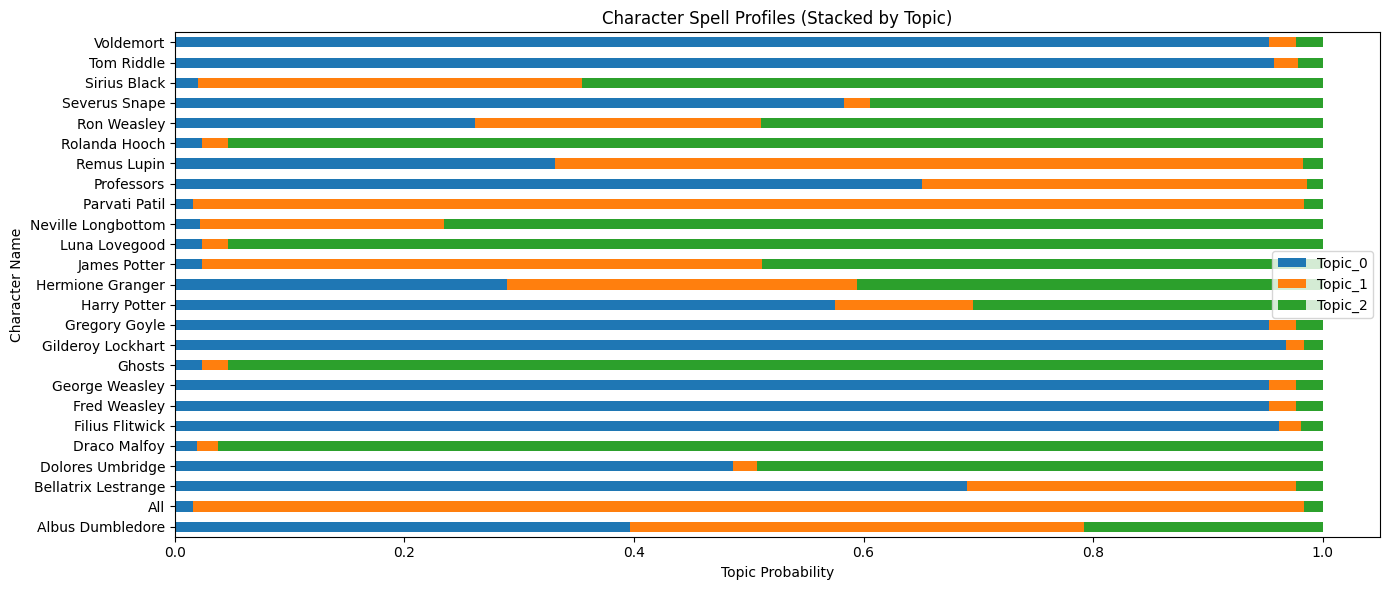

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
character_topic_profiles.set_index("Character Name")[topic_cols].plot(
    kind='barh', stacked=True, ax=ax
)
ax.set_xlabel("Topic Probability")
ax.set_title("Character Spell Profiles (Stacked by Topic)")
plt.tight_layout()

## Character Topic Affinity Heatmap

This heatmap shows the topic probabilities for a selected group of important characters. Each row represents one character, and each column represents one learned topic.

The numbers inside the cells show the exact probability values. Higher values mean that the character is more strongly associated with that topic based on the spells they use.

The characters are sorted by `Topic_0`, so characters with the strongest association to that topic appear at the top. This makes it easier to compare character profiles and see which characters are more similar or different in their spell usage.

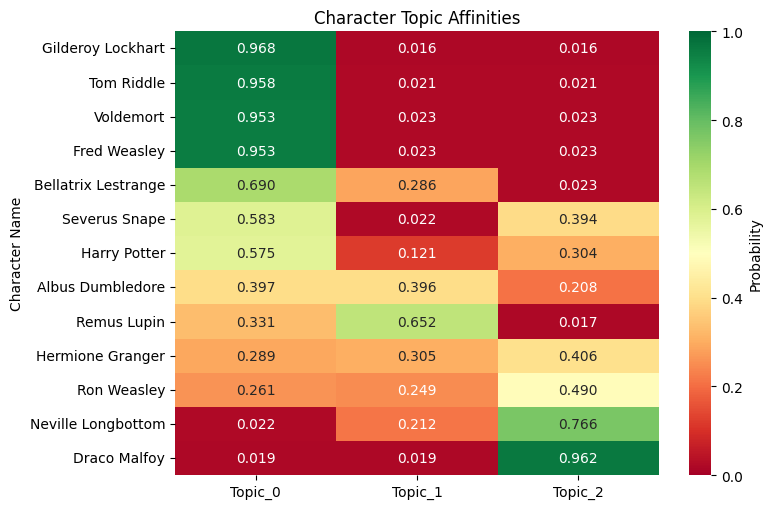

In [52]:
import seaborn as sns

# Select specific characters (modify this list as needed)
selected_characters = [
    "Harry Potter",
    "Voldemort",
    "Albus Dumbledore",
    "Hermione Granger",
    "Ron Weasley",
    "Severus Snape",
    "Minerva McGonagall",
    "Bellatrix Lestrange",
    "Neville Longbottom",
    "Remus Lupin",
    "Fred Weasley",
    "Draco Malfoy",
    "Tom Riddle",
    "Pavarti Patil",
    "Gilderoy Lockhart"
]

# Filter to only characters that exist in the data
available_characters = character_topic_profiles["Character Name"].tolist()
selected_characters = [char for char in selected_characters if char in available_characters]

# Create heatmap with selected characters
filtered_data = character_topic_profiles[
    character_topic_profiles["Character Name"].isin(selected_characters)
].set_index("Character Name")[topic_cols]

# Sort by Topic_0 probability in descending order
filtered_data = filtered_data.sort_values("Topic_0", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(selected_characters) * 0.4)))
sns.heatmap(
    filtered_data,
    annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, 
    cbar_kws={'label': 'Probability'},
    vmin=0, vmax=1
)
ax.set_title("Character Topic Affinities")
plt.tight_layout()

## Character Spell Personality Map

This plot uses PCA to reduce each character’s three topic probabilities into two dimensions. Each point represents one character.

Characters that appear close together have similar spell-topic profiles, meaning they use spells with similar topic distributions. Characters that are far apart have more different magical profiles.

The x-axis and y-axis are the first two principal components, which summarize most of the variation in the character topic profiles. 

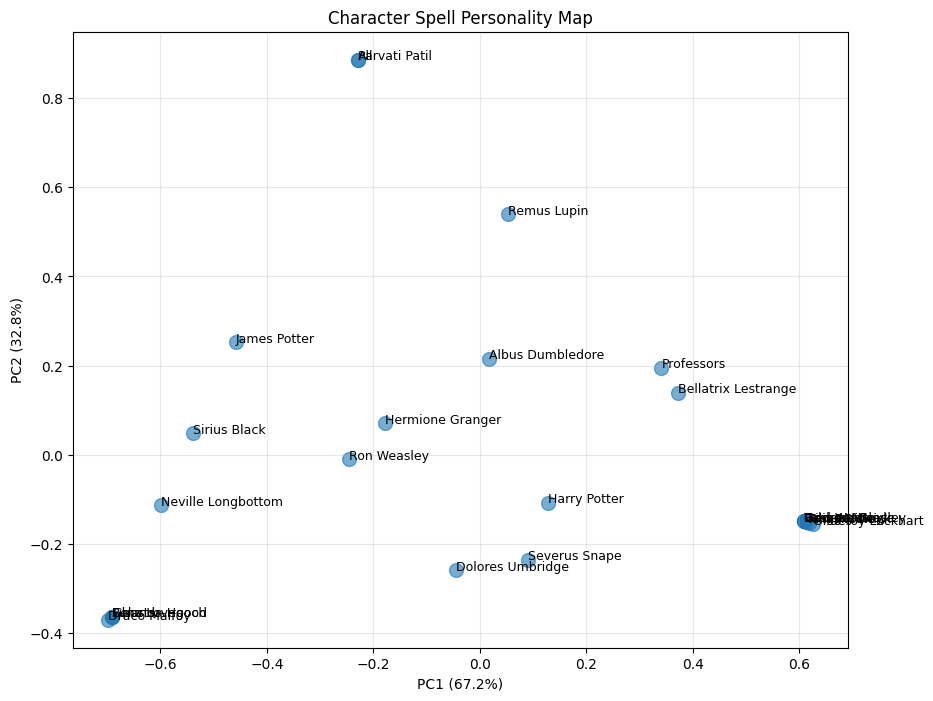

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(character_topic_profiles[topic_cols])

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=100, alpha=0.6)
for idx, char in enumerate(character_topic_profiles["Character Name"]):
    ax.annotate(char, (coords[idx, 0], coords[idx, 1]), fontsize=9)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title("Character Spell Personality Map")
plt.grid(True, alpha=0.3)

## Character Magic Profiles Comparison

This radar plot compares the topic profiles of selected characters. Each axis represents one of the learned spell topics, and each character is shown as a connected shape across the three topic probabilities.

A character with a larger value on one axis is more strongly associated with that topic. This makes it easy to compare characters directly and see whether they have similar or different magical profiles.

In this plot, Harry Potter, Voldemort, and Albus Dumbledore are compared based on the topics of the spells they use in the dialogue.

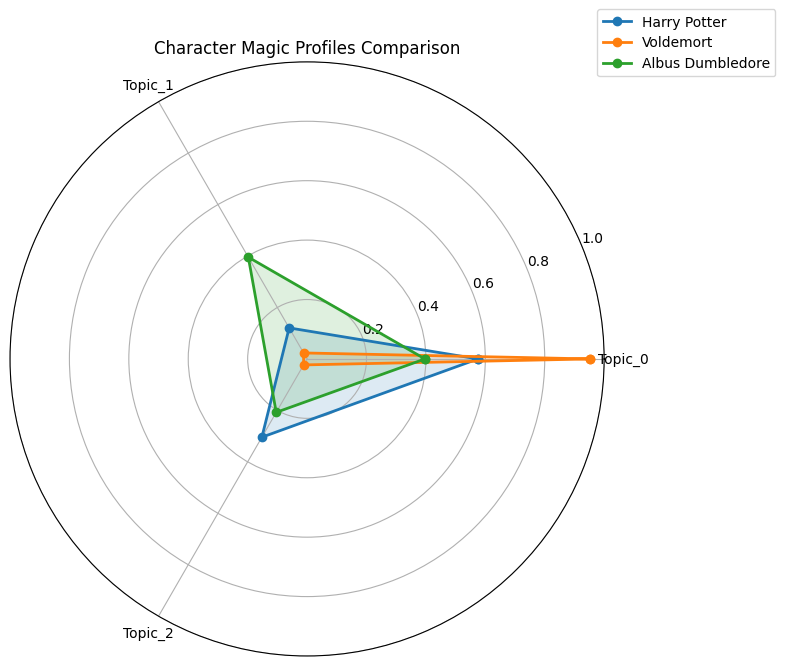

In [54]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

characters_to_plot = ['Harry Potter', 'Voldemort', 'Albus Dumbledore']
angles = np.linspace(0, 2*np.pi, len(topic_cols), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for char in characters_to_plot:
    if char in character_topic_profiles["Character Name"].values:
        row = character_topic_profiles[character_topic_profiles["Character Name"] == char].iloc[0]
        values = row[topic_cols].tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=char)
        ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(topic_cols)
ax.set_ylim(0, 1)
ax.set_title("Character Magic Profiles Comparison")
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

In [55]:
# Show min/max/mean for each topic
for col in topic_cols:
    print(f"{col}:")
    print(f"  Mean: {character_topic_profiles[col].mean():.3f}")
    print(f"  Std:  {character_topic_profiles[col].std():.3f}")
    print(f"  Min:  {character_topic_profiles[col].min():.3f}")
    print(f"  Max:  {character_topic_profiles[col].max():.3f}")

Topic_0:
  Mean: 0.446
  Std:  0.391
  Min:  0.016
  Max:  0.968
Topic_1:
  Mean: 0.224
  Std:  0.286
  Min:  0.016
  Max:  0.968
Topic_2:
  Mean: 0.330
  Std:  0.360
  Min:  0.013
  Max:  0.962
